**Gaussian Mixture Models (GMMs)**

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/fbourgey/fre-gy-7773-mlfe/blob/main/08_gaussian_mixture_models.ipynb)

# Imports

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.stats import chi2, multivariate_normal, norm
from stats.gaussian_mixtures import gaussian_mixture_pdf


sns.set_theme("talk")
sns.set_style("whitegrid")
mpl.rcParams["figure.figsize"] = (8, 6)
SEED = 1234

# Sampling from a GMM

In [2]:
# Define the parameters of the Gaussian mixture model

weights = np.array([0.1, 0.3, 0.0])  # mixture weights (must sum to 1)
weights[-1] = 1 - weights[:-1].sum()  # ensure weights sum to 1
means = np.array([0.2, -0.4, 0.5])
variances = np.array([0.05, 0.02, 0.03])  

print("Weights:", weights)
print("Means:", means)
print("Variances:", variances)

Weights: [0.1 0.3 0.6]
Means: [ 0.2 -0.4  0.5]
Variances: [0.05 0.02 0.03]


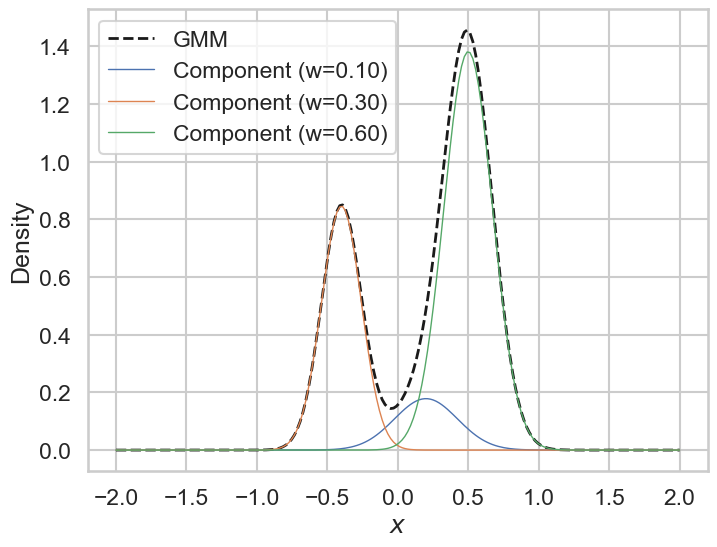

In [3]:
xs = np.linspace(-2, 2, 200)
pdf_mix = gaussian_mixture_pdf(xs, weights, means, variances)
fig, ax = plt.subplots()
ax.plot(xs, pdf_mix, "k--", lw=2, label="GMM")
for w, m, v in zip(weights, means, variances, strict=True):
    pdf_comp = w * norm.pdf(xs, loc=m, scale=np.sqrt(v))
    ax.plot(xs, pdf_comp, lw=1, label=f"Component (w={w:.2f})")
ax.set_xlabel("$x$")
ax.set_ylabel("Density")
ax.legend()
plt.show()

- To sample from a Gaussian mixture model, for each sample:

    - Pick a component $k \in \{1, \ldots, K\}$ with probability $\{\pi_1, \ldots, \pi_K\}$
    - Draw a sample from the selected Gaussian component $x_i \sim \mathcal{N}(\mu_k, \Sigma_k)$



In [4]:
n_components = len(weights)
n_samples = 10**4

rng = np.random.default_rng(SEED)
component_indices = rng.choice(n_components, size=n_samples, p=weights)
gmm_samples = np.array(
    [rng.normal(loc=means[i], scale=np.sqrt(variances[i])) for i in component_indices]
)

In [5]:
component_indices[:30]

array([2, 1, 2, 1, 1, 1, 1, 1, 2, 1, 2, 2, 2, 2, 2, 2, 2, 1, 1, 2, 0, 2,
       2, 2, 0, 2, 2, 2, 0, 1])

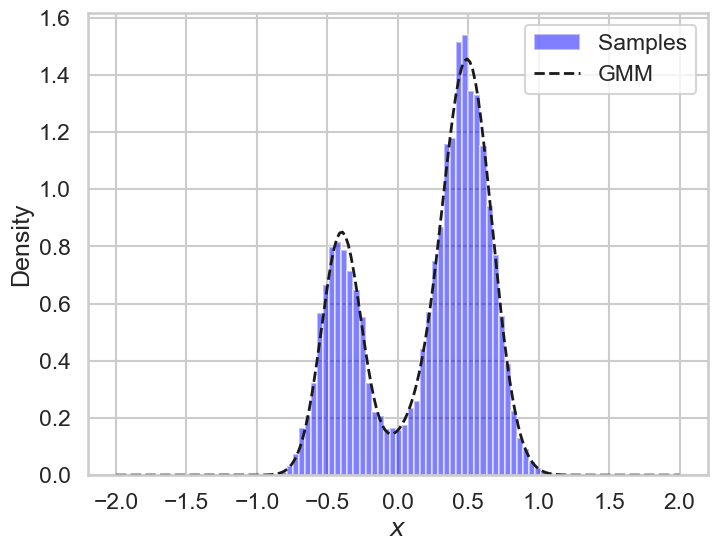

In [6]:
fig, ax = plt.subplots()
ax.hist(gmm_samples, bins=50, density=True, alpha=0.5, label="Samples", color="blue")
ax.plot(xs, pdf_mix, "k--", lw=2, label="GMM")
ax.set_xlabel("$x$")
ax.set_ylabel("Density")
ax.legend()
plt.show()

# Load data

[Old Faithful dataset](https://stat.ethz.ch/R-manual/R-devel/library/datasets/html/faithful.html)

- Description
    - Waiting time between eruptions and the duration of the eruption for the 
    Old Faithful geyser in Yellowstone National Park, Wyoming, USA.
- Format
    - A data frame with 272 observations on 2 variables.
        - eruptions: numeric, the eruption time (in minutes)
        - waiting: numeric, the waiting time to the next eruption (in minutes)

In [7]:
df = pd.read_csv("data/old_faithful.csv", index_col=0)

In [ ]:
df.shape

1      3.600
2      1.800
3      3.333
4      2.283
5      4.533
       ...  
268    4.117
269    2.150
270    4.417
271    1.817
272    4.467
Name: eruptions, Length: 272, dtype: float64

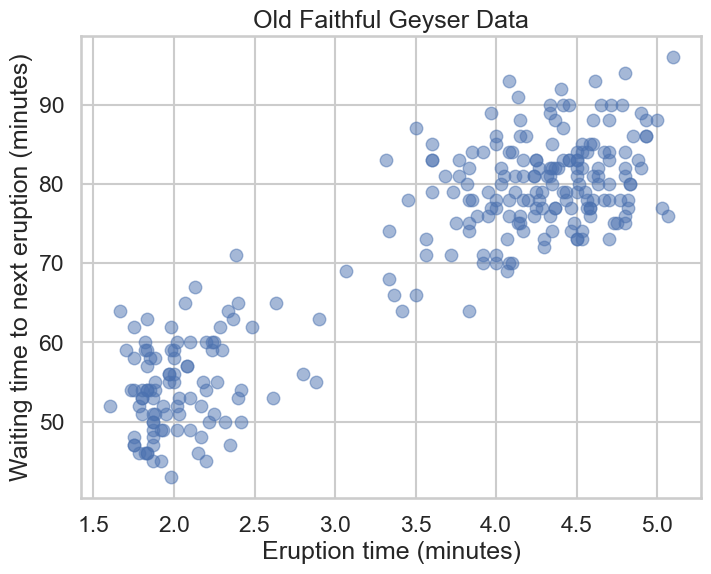

In [12]:
fig, ax = plt.subplots()
ax.plot(df.eruptions, df.waiting, "o", alpha=0.5)
ax.set_xlabel("Eruption time (minutes)")
ax.set_ylabel("Waiting time to next eruption (minutes)")
ax.set_title("Old Faithful Geyser Data")
plt.show()

In [13]:
data = df.to_numpy()

In [15]:
mean_estim, cov_estim = multivariate_normal.fit(data)

Contour plot

In [16]:
x = np.linspace(data[:, 0].min(), data[:, 0].max(), 200)
y = np.linspace(data[:, 1].min(), data[:, 1].max(), 200)
X, Y = np.meshgrid(x, y)
pos = np.dstack((X, Y))
Z = multivariate_normal.pdf(pos, mean=mean_estim, cov=cov_estim)

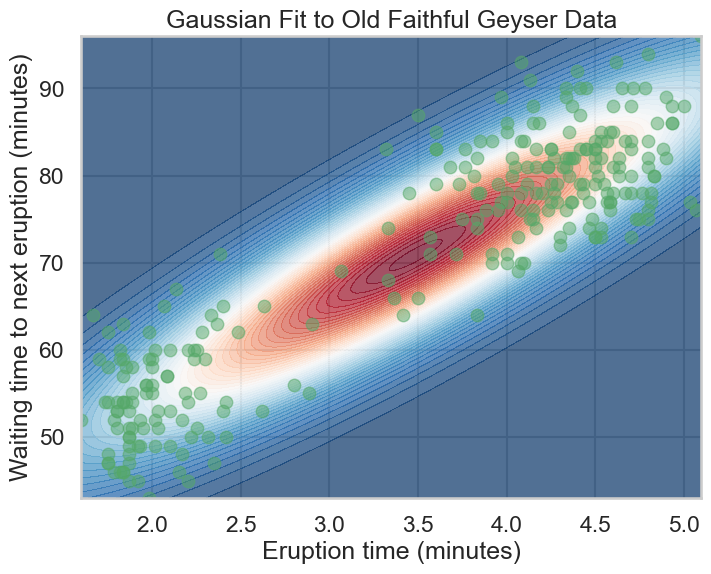

In [17]:
fig, ax = plt.subplots()
ax.contourf(X, Y, Z, levels=50, cmap="RdBu_r", alpha=0.7)
ax.plot(data[:, 0], data[:, 1], "go", alpha=0.5)
ax.set_xlabel("Eruption time (minutes)")
ax.set_ylabel("Waiting time to next eruption (minutes)")
ax.set_title("Gaussian Fit to Old Faithful Geyser Data")
plt.show()

Another contour plot

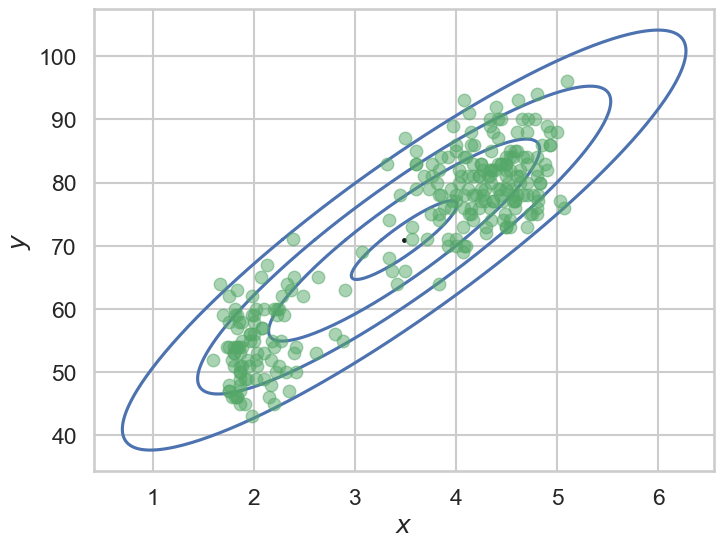

In [18]:
# ellipse "radii" for chosen enclosed probabilities
probs = [0.1, 0.50, 0.80, 0.95]
cs = chi2.ppf(probs, df=2)  # c-values for the Mahalanobis distance^2

# eigen-decomposition
lam, V = np.linalg.eigh(cov_estim)  # lam: eigenvalues (>=0), V: eigenvectors (columns)
L = V @ np.diag(np.sqrt(lam))  # linear map turning unit circle -> 1-sigma ellipse

# parametric unit circle
theta = np.linspace(0, 2 * np.pi, 400)
unit = np.vstack((np.cos(theta), np.sin(theta)))  # shape (2, 400)

fig, ax = plt.subplots()
for p, c in zip(probs, cs, strict=True):
    # scale by sqrt(c) to get the desired ellipse
    ellipse = mean_estim.reshape(2, 1) + np.sqrt(c) * (L @ unit)
    ax.plot(ellipse[0], ellipse[1], "b-", label=f"{int(100 * p)}% probability")

ax.plot(mean_estim[0], mean_estim[1], ".k", ms=5)  # plot mean
ax.plot(data[:, 0], data[:, 1], "go", alpha=0.5)
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
plt.show()

## Expectation-Maximization (EM) algorithm for GMMs

- Step 1: Initialize the parameters (means, covariances, and mixture weights) of the Gaussian components and compute the initial log-likelihood.
- Step 2: E-step: Compute the responsibilities (posterior probabilities) for each data point belonging to each Gaussian component.
- Step 3: M-step: Update the parameters of the Gaussian components using the responsibilities computed in the E-step.
- Step 4: Compute the log-likelihood of the data given the current parameters.
- Step 5: Check for convergence (e.g., if the change in log-likelihood is below a certain threshold). If not converged, return to Step 2.

In [ ]:
# Initialize parameters

mean_0 = np.array([1.5, 70])
mean_1 = np.array([4, 80])
means = np.array([mean_0, mean_1]).reshape(2, 2)

cov_0 = np.array([[0.2, 2], [2, 40]])
cov_1 = np.array([[0.5, 4], [3, 40]])
covariances = np.array([cov_0, cov_1])

weight_0 = 0.5
weight_1 = 0.5
weights = np.array([weight_0, weight_1]).reshape(-1, 1)

x_data = df.to_numpy()

weights_pdfs = np.array(
    [
        # TODO
    ]
)  # shape (n_components, n_samples)
loglik = np.sum(np.log(np.sum(weights_pdfs, axis=0)))

In [ ]:
TOL = 1e-8
n_steps = 20

for i in range(n_steps):
    # 1) EM initialization - compute log-likelihood

    print(f"Step {i}: log-likelihood is {loglik:.2f}")

    # 2) E-step - compute responsibilities
    resp = weights_pdfs / np.sum(weights_pdfs, axis=0)

    # 3) M-step - update parameters
    N_k = #TODO
    weights_new =#TODO
    means_new = #TODO
    covariances_new = #TODO
    weights_pdfs = np.array(
        [
            #TODO
        ]
    )  # shape (n_components, n_samples)
    loglik_new = #TODO
    # if np.abs(loglik_new - loglik) < TOL:
    #     print("Converged!")
    #     break

    weights, means, covariances, loglik = (
        weights_new,
        means_new,
        covariances_new,
        loglik_new,
    )

Step 0: log-likelihood is -2018.45
Step 1: log-likelihood is -1259.95
Step 2: log-likelihood is -1237.53
Step 3: log-likelihood is -1215.64
Step 4: log-likelihood is -1202.07
Step 5: log-likelihood is -1190.25
Step 6: log-likelihood is -1174.83
Step 7: log-likelihood is -1156.38
Step 8: log-likelihood is -1142.40
Step 9: log-likelihood is -1135.50
Step 10: log-likelihood is -1131.97
Step 11: log-likelihood is -1130.53
Step 12: log-likelihood is -1130.29
Step 13: log-likelihood is -1130.27
Step 14: log-likelihood is -1130.26
Step 15: log-likelihood is -1130.26
Step 16: log-likelihood is -1130.26
Step 17: log-likelihood is -1130.26
Step 18: log-likelihood is -1130.26
Step 19: log-likelihood is -1130.26


In [20]:
print("Optimal parameters:\n")
print("weights:", weights.ravel(), "\n")
print("means:", means, "\n")
print("covariances:", covariances)

Optimal parameters:

weights: [0.35587285 0.64412715] 

means: [[ 2.03638843 54.47851612]
 [ 4.28966195 79.9681149 ]] 

covariances: [[[ 0.06916765  0.43516741]
  [ 0.43516741 33.69728061]]

 [[ 0.16996846  0.94060969]
  [ 0.94060969 36.04621548]]]


In [21]:
x = np.linspace(data[:, 0].min(), data[:, 0].max(), 200)
y = np.linspace(data[:, 1].min(), data[:, 1].max(), 200)
X, Y = np.meshgrid(x, y)
pos = np.dstack((X, Y))
Z = sum(
    multivariate_normal.pdf(pos, mean=mean_estim, cov=cov_estim)
    for mean_estim, cov_estim in zip(means, covariances)
)

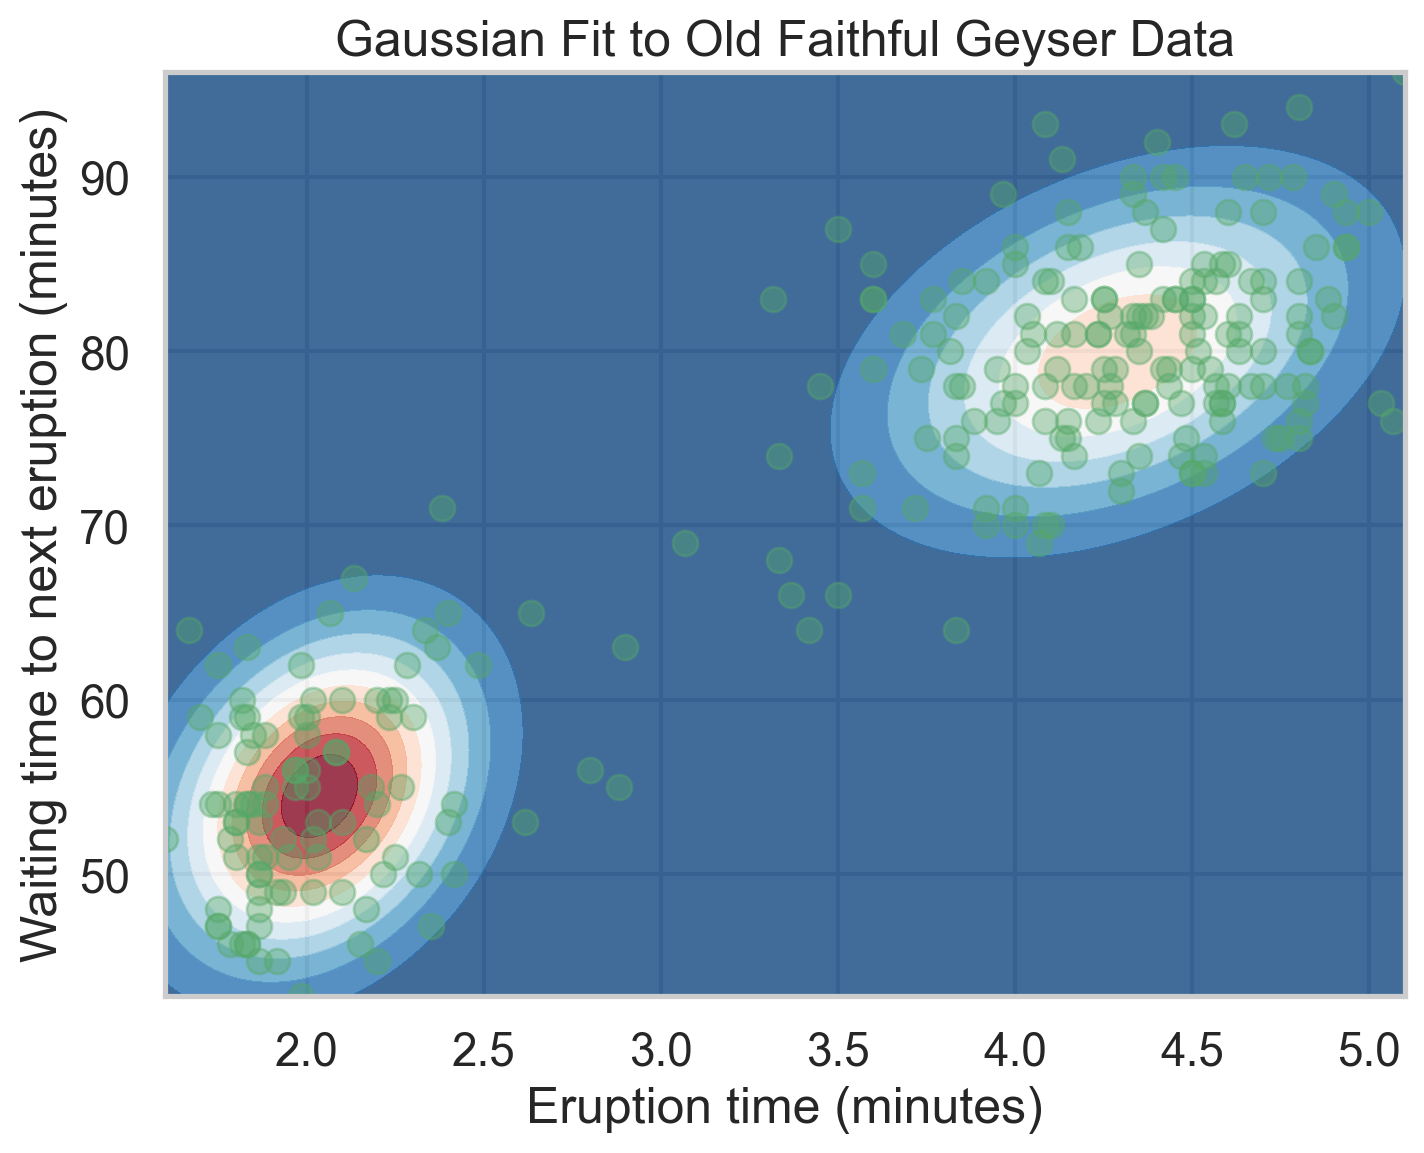

In [22]:
fig, ax = plt.subplots()
ax.plot(x_data[:, 0], x_data[:, 1], "go", alpha=0.4)
ax.contourf(X, Y, Z, levels=10, cmap="RdBu_r", alpha=0.8)
ax.set_xlabel("Eruption time (minutes)")
ax.set_ylabel("Waiting time to next eruption (minutes)")
ax.set_title("Gaussian Fit to Old Faithful Geyser Data")
plt.show()

We can compare our results to the [GaussianMixture](https://scikit-learn.org/stable/modules/generated/sklearn.mixture.GaussianMixture.html) implementation from `sklearn`.

In [ ]:
from sklearn.mixture import GaussianMixture

gm = #TODO
gm.means_, gm.covariances_, gm.weights_

(array([[ 2.03652149, 54.47986018],
        [ 4.28977944, 79.96953298]]),
 array([[[ 0.06927449,  0.43627723],
         [ 0.43627723, 33.70493352]],
 
        [[ 0.16982046,  0.93871793],
         [ 0.93871793, 36.02497019]]]),
 array([0.35592745, 0.64407255]))

In [24]:
gm.means_

array([[ 2.03652149, 54.47986018],
       [ 4.28977944, 79.96953298]])

In [25]:
means

array([[ 2.03638843, 54.47851612],
       [ 4.28966195, 79.9681149 ]])

In [26]:
gm.covariances_

array([[[ 0.06927449,  0.43627723],
        [ 0.43627723, 33.70493352]],

       [[ 0.16982046,  0.93871793],
        [ 0.93871793, 36.02497019]]])

In [27]:
covariances

array([[[ 0.06916765,  0.43516741],
        [ 0.43516741, 33.69728061]],

       [[ 0.16996846,  0.94060969],
        [ 0.94060969, 36.04621548]]])

In [28]:
weights

array([[0.35587285],
       [0.64412715]])

In [29]:
gm.weights_

array([0.35592745, 0.64407255])